<a href="https://colab.research.google.com/github/EnzoSalvini/Calculo_numerico/blob/main/Atv2CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividade 1:
Espaçamento dy: 0.0005
dt_max permitido: 0.0012499999999999998

--- Caso A (dt = 0.001) ---
r = 0.4000000000000001
Classificação: Estável

--- Caso B (dt = 0.002) ---
r = 0.8000000000000002
Classificação: Instável

Atividade 2:
dt=0.001, float32: 2000 passos sem overflow.
Tipo: float32 | dt: 0.001 | r: 0.40 | Status: Sem overflow (2000 passos)
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
Tipo: float32 | dt: 0.002 | r: 0.80 | Status: Overflow no passo 121
dt=0.001, float64: 2000 passos sem overflow.
Tipo: float64 | dt: 0.001 | r: 0.40 | Status: Sem overflow (2000 passos)
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add
Tipo: float64 | dt: 0.002 | r: 0.80 | Status: Overflow no passo 917

Atividade 3: A velocidade do fluido fisicamente deve ficar sempre entre 0m/s e 1m/s.
No caso instável r=0,8, o coeficiente central da equação de atualização 1-2r torna-se negativo 1-1,6 = -0,6,
fazendo com que os erros nu

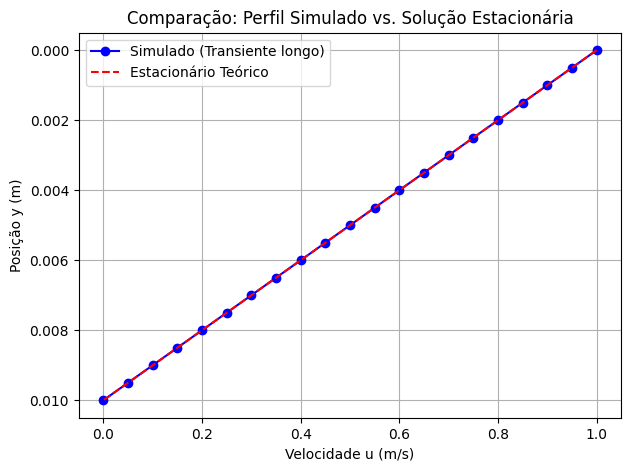


Atividade 7: O refinamento da malha diminui Delta y, o que exige passos de tempo Delta t proporcionalmente menores para satisfazer a condição de estabilidade r <= 1/2.
Ajustar o passo de tempo Delta t para respeitar o limite de estabilidade foi a única alteração capaz de corrigir a causa raiz da falha numérica, e não a troca de tipo de dado.

Prints e gráficos originais do collab.

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


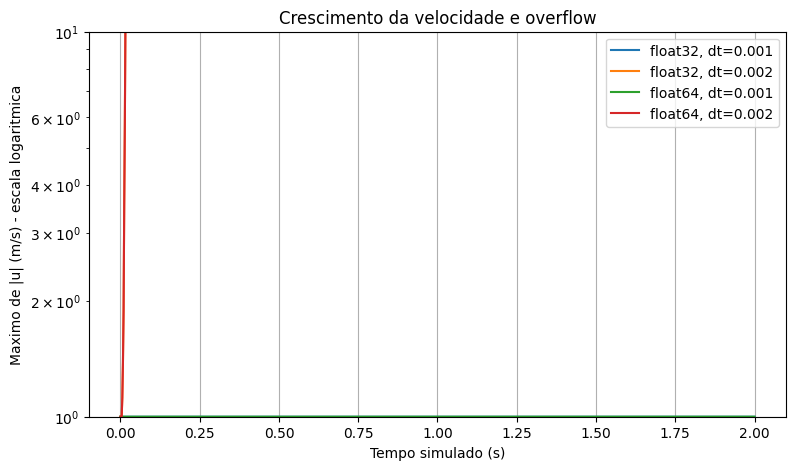

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

H = 0.01
pontos = 21
nu = 1e-4

dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

# Casos A e B
dt_A = 0.001
dt_B = 0.002

r_A = nu * dt_A / dy**2
r_B = nu * dt_B / dy**2

print("Atividade 1:")
print(f"Espaçamento dy: {dy}")
print(f"dt_max permitido: {dt_max}\n")

print(f"--- Caso A (dt = {dt_A}) ---")
print(f"r = {r_A}")
print("Classificação:", "Estável" if r_A <= 0.5 else "Instável")

print(f"\n--- Caso B (dt = {dt_B}) ---")
print(f"r = {r_B}")
print("Classificação:", "Estável" if r_B <= 0.5 else "Instável")
print()

print("Atividade 2:")
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        res = simular(dt=dt, tipo=tipo)
        tipo_nome = tipo.__name__
        status = f"Overflow no passo {res['falha']}" if res["falha"] is not None else "Sem overflow (2000 passos)"

        print(f"Tipo: {tipo_nome} | dt: {dt} | r: {res['r']:.2f} | Status: {status}")
print()
print('Atividade 3: A velocidade do fluido fisicamente deve ficar sempre entre 0m/s e 1m/s.\n'
      'No caso instável r=0,8, o coeficiente central da equação de atualização 1-2r torna-se negativo 1-1,6 = -0,6,\n'
      'fazendo com que os erros numéricos comecem a oscilar e crescer exponencialmente, gerando velocidades não físicas antes mesmo do estouro do computador.\n')
print('Atividade 4: Mudar de float32 para float64 não elimina a instabilidade. O float64 possui uma faixa de representação muito maior\n'
 '(~1,8e308 contra 3,4e38 do float32), o que significa apenas que ele aguentará mais alguns passos de crescimento descontrolado antes de disparar o erro de overflow,\n'
  'mas a raiz matemática do problema (o erro de discretização por r > 0,5) continua lá.\n')

# 1. Calculando os novos limites com 41 pontos
pontos_novo = 41
dy_novo = 0.01 / (pontos_novo - 1)
dt_max_novo = dy_novo**2 / (2 * 1e-4)
print("Atividade 5: ")
print(f"Novo dy: {dy_novo}")
print(f"Novo dt_max: {dt_max_novo}")

# 2. Testando com o dt antigo (0.001) na malha nova (vai falhar mais rápido)
res_malha_ruim = simular(dt=0.001, tipo=np.float32, pontos=41)
print(f"Com dt=0.001 (falha): {res_malha_ruim['falha']}")

# 3. Testando com um dt seguro abaixo do novo limite (ex: dt = 0.0002)
res_malha_bom = simular(dt=0.0002, tipo=np.float32, pontos=41)
print(f"Com dt=0.0002 (falha): {res_malha_bom['falha']}")
print()
print("Atividade 6: ")
# Executa uma simulação estável e longa (ex: dt=0.001, float64)
res_estavel = simular(dt=0.001, tipo=np.float64, passos=3000)

y = res_estavel["y"]
u_simulado = res_estavel["u"]

# Solução analítica estacionária
U = 1.0
H = 0.01
u_estacionario = U * (1 - y / H)

# Calculando o erro máximo E_infinito
E_infinito = np.max(np.abs(u_simulado - u_estacionario))
print(f"Erro máximo E_infinito: {E_infinito}")

# Plotando a comparação
plt.figure(figsize=(7, 5))
plt.plot(u_simulado, y, 'bo-', label="Simulado (Transiente longo)")
plt.plot(u_estacionario, y, 'r--', label="Estacionário Teórico")
plt.ylabel("Posição y (m)")
plt.xlabel("Velocidade u (m/s)")
plt.title("Comparação: Perfil Simulado vs. Solução Estacionária")
plt.gca().invert_yaxis()
plt.grid(True)
plt.legend()
plt.show()
print()

print('Atividade 7: O refinamento da malha diminui Delta y, o que exige passos de tempo Delta t proporcionalmente menores para satisfazer a condição de estabilidade r <= 1/2.\n'
 'Ajustar o passo de tempo Delta t para respeitar o limite de estabilidade foi a única alteração capaz de corrigir a causa raiz da falha numérica, e não a troca de tipo de dado.\n')
print("Prints e gráficos originais do collab.\n")
print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()